In [2]:
import pandas as pd

centralized = pd.read_csv("../results/baselines.csv")

fl_iid = pd.read_csv("../results/fl_iid_final.csv")
fl_noniid = pd.read_csv("../results/fl_noniid_final.csv")

fl_dp_iid = pd.read_csv("../results/fl_dp_final.csv")
fl_dp_noniid = pd.read_csv("../results/fl_dp_noniid_final.csv")

In [3]:
results = pd.concat([
    centralized,
    fl_iid,
    fl_noniid,
    fl_dp_iid,
    fl_dp_noniid
], ignore_index=True)

results

,model,accuracy,precision,recall,f1,roc_auc
0,CatBoost,0.874144,0.821439,0.985683,0.896097,0.984053
1,RandomForest,0.870864,0.817428,0.985595,0.893669,0.979282
2,NeuralNet,0.907229,0.916435,0.914939,0.915686,0.977254
3,FederatedNN_IID,0.874800,0.828654,0.974014,0.895473,0.979090
4,FederatedNN_nonIID,0.799215,0.732984,0.999404,0.845708,0.974746
5,FederatedNN_DP,0.820313,0.761241,0.981492,0.857448,0.956565
6,FederatedNN_DP_nonIID,0.811531,0.748703,0.989985,0.852602,0.947337


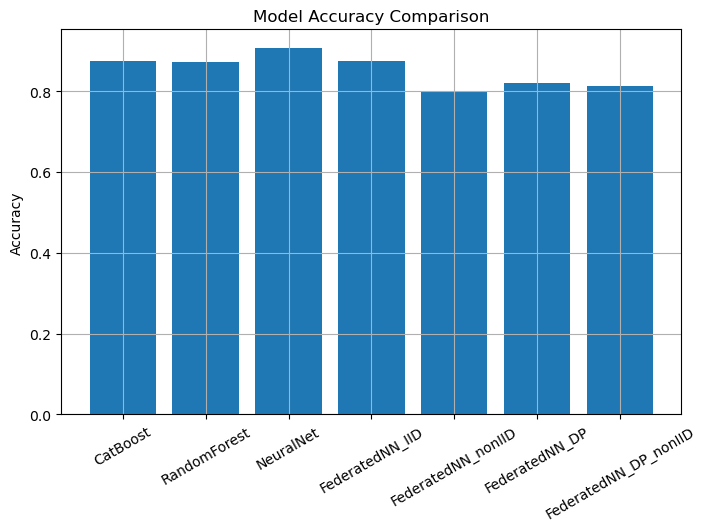

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["model"], results["accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(True)

plt.show()

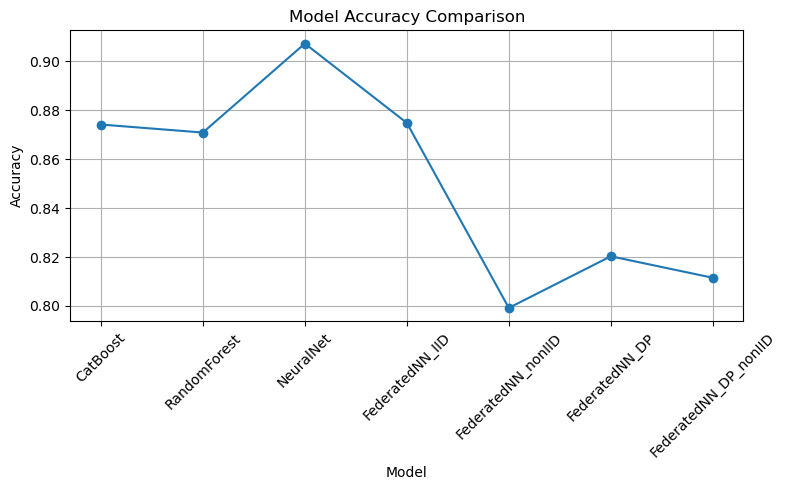

In [5]:
import matplotlib.pyplot as plt

models = results["model"]
accuracy = results["accuracy"]

plt.figure(figsize=(8,5))

plt.plot(models, accuracy, marker="o")

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

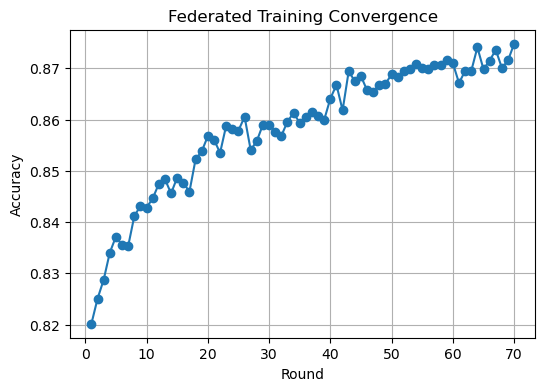

In [6]:
fl_rounds = pd.read_csv("../results/fl_iid_rounds.csv")

plt.figure(figsize=(6,4))
plt.plot(fl_rounds["round"], fl_rounds["accuracy"], marker='o')

plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Federated Training Convergence")
plt.grid(True)

plt.show()

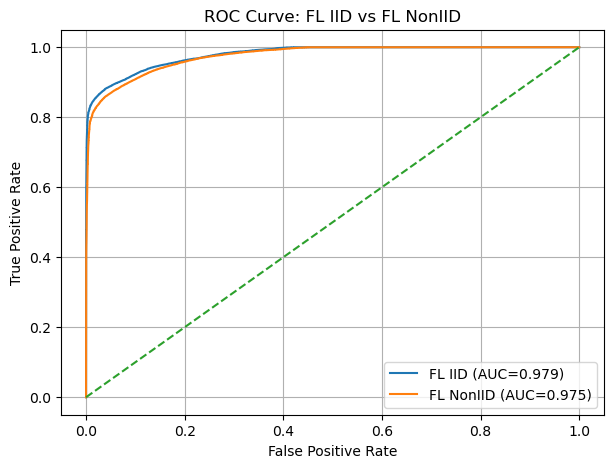

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

iid = pd.read_csv("../results/fl_iid_predictions.csv")
noniid = pd.read_csv("../results/fl_noniid_predictions.csv")

plt.figure(figsize=(7,5))

# FL IID
fpr, tpr, _ = roc_curve(iid["y_true"], iid["y_prob"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"FL IID (AUC={roc_auc:.3f})")

# FL NonIID
fpr, tpr, _ = roc_curve(noniid["y_true"], noniid["y_prob"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"FL NonIID (AUC={roc_auc:.3f})")

# random classifier
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: FL IID vs FL NonIID")
plt.legend()
plt.grid()

plt.show()

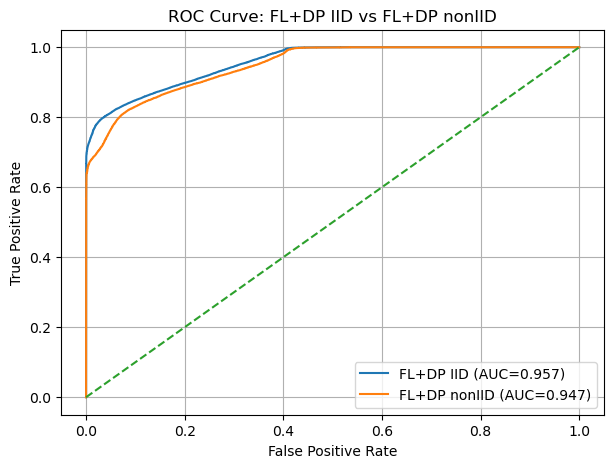

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

dp_iid = pd.read_csv("../results/fl_dp_iid_predictions.csv")
dp_noniid = pd.read_csv("../results/fl_dp_noniid_predictions.csv")

plt.figure(figsize=(7,5))

# FL + DP IID
fpr, tpr, _ = roc_curve(dp_iid["y_true"], dp_iid["y_prob"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"FL+DP IID (AUC={roc_auc:.3f})")

# FL + DP nonIID
fpr, tpr, _ = roc_curve(dp_noniid["y_true"], dp_noniid["y_prob"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"FL+DP nonIID (AUC={roc_auc:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: FL+DP IID vs FL+DP nonIID")
plt.legend()
plt.grid(True)
plt.show()

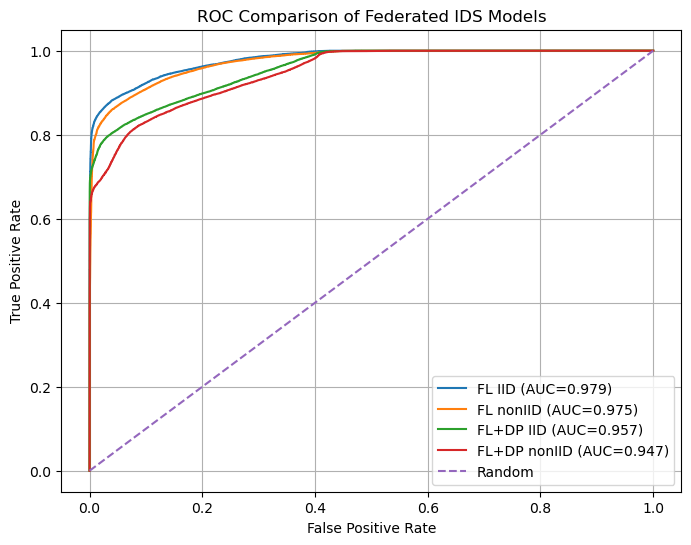

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model_files = {
    "FL IID": "../results/fl_iid_predictions.csv",
    "FL nonIID": "../results/fl_noniid_predictions.csv",
    "FL+DP IID": "../results/fl_dp_iid_predictions.csv",
    "FL+DP nonIID": "../results/fl_dp_noniid_predictions.csv"
}

plt.figure(figsize=(8,6))

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    fpr, tpr, _ = roc_curve(df["y_true"], df["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], '--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Federated IDS Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

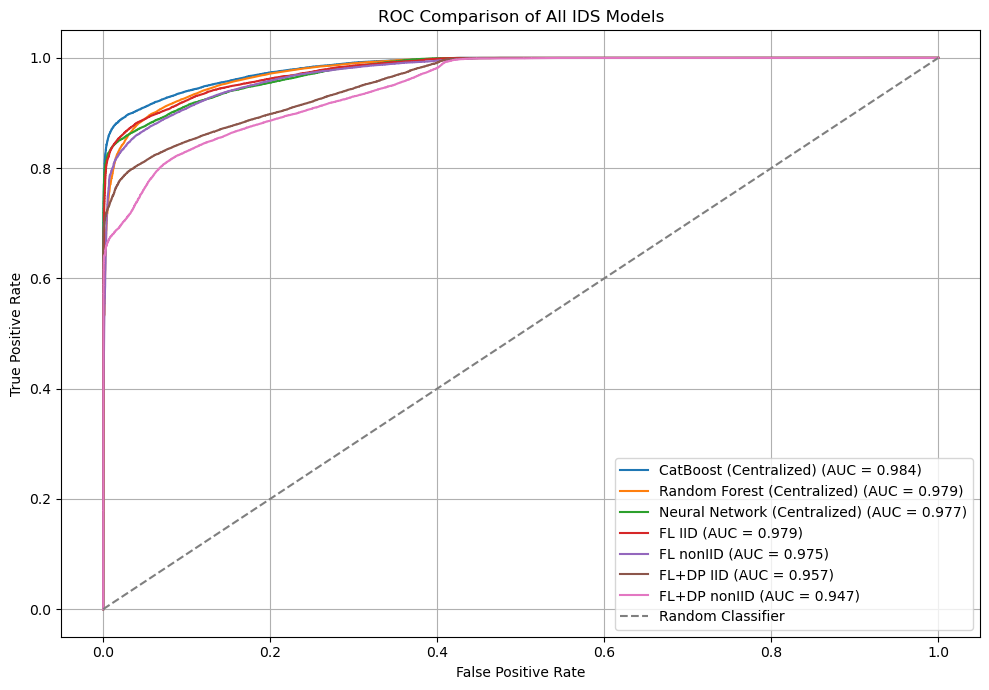

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model_files = {
    "CatBoost (Centralized)": "../results/catboost_predictions.csv",
    "Random Forest (Centralized)": "../results/randomforest_predictions.csv",
    "Neural Network (Centralized)": "../results/neuralnet_predictions.csv",
    "FL IID": "../results/fl_iid_predictions.csv",
    "FL nonIID": "../results/fl_noniid_predictions.csv",
    "FL+DP IID": "../results/fl_dp_iid_predictions.csv",
    "FL+DP nonIID": "../results/fl_dp_noniid_predictions.csv"
}

plt.figure(figsize=(10, 7))

for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    fpr, tpr, _ = roc_curve(df["y_true"], df["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], '--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of All IDS Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
def compute_exposure(model_type, dp=False):
    """
    Returns relative exposure based on mechanism
    Lower = better privacy
    """
    
    if model_type == "centralized":
        data_shared = 1.0      # full dataset
        sensitivity = 1.0      # raw data
    elif model_type == "federated":
        data_shared = 0.1      # only model updates
        sensitivity = 0.5      # gradients leak info
    else:
        raise ValueError("Unknown model type")
    
    if dp:
        sensitivity *= 0.3     # DP reduces leakage
    
    return data_shared * sensitivity

In [12]:
models = [
    "Centralized NN",
    "FL IID",
    "FL non-IID",
    "FL+DP IID",
    "FL+DP non-IID"
]

exposure = [
    compute_exposure("centralized"),
    compute_exposure("federated"),
    compute_exposure("federated"),
    compute_exposure("federated", dp=True),
    compute_exposure("federated", dp=True)
]

In [13]:
import numpy as np

privacy_score = 1 / exposure

# smoother scaling (instead of aggressive normalization)
privacy_score = np.log1p(privacy_score)

# normalize for plotting
privacy_score = (privacy_score - privacy_score.min()) / (privacy_score.max() - privacy_score.min())

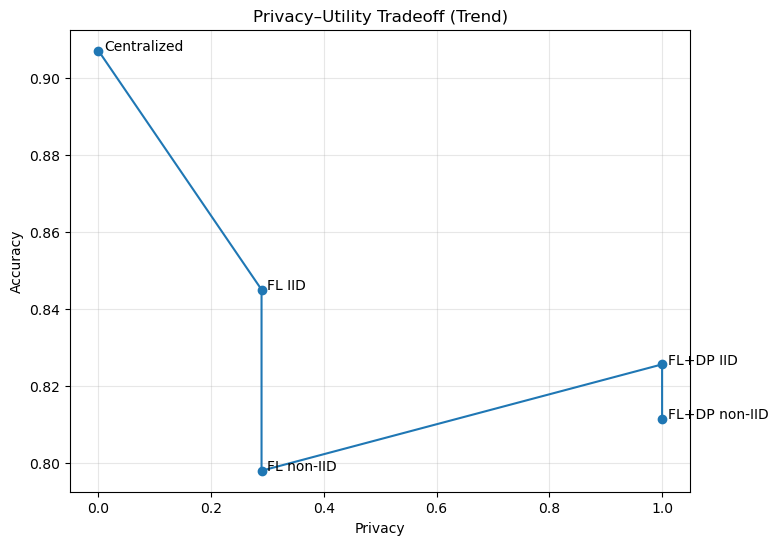

In [19]:
import matplotlib.pyplot as plt

models = ["Centralized", "FL IID", "FL non-IID", "FL+DP IID", "FL+DP non-IID"]
accuracy = [0.907, 0.845, 0.798, 0.8256, 0.8115]

# use your computed privacy_score
plt.figure(figsize=(8,6))

plt.plot(privacy_score, accuracy, marker='o')

for i, model in enumerate(models):
    plt.text(privacy_score[i] + 0.01, accuracy[i], model)

plt.xlabel("Privacy")
plt.ylabel("Accuracy")
plt.title("Privacy–Utility Tradeoff (Trend)")

plt.grid(alpha=0.3)
plt.show()